# Завантаження бібліотек та набору даних

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import warnings


In [2]:
import plotly.io as pio
pio.renderers.default = "svg"

In [3]:
# Вимкнення повідомлень про попередження
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_excel('large_italian_restaurant_sales.xlsx')


In [5]:
#Вибираємо кольорову палітру для створення візуалізацій
palette_of_df = ['#1C2E4A', '#67A9CF', '#1B9E77', '#BDC9E1']


# Першим етапом дослідження є первинне знайомство з даними, очищення їх від аномалій або дублікатів, заповнення пропущених значень, перевірка точності розрахунків тощо.

In [6]:
#Ознайомлення з даними
df.head()


,Date,Time,Menu Item,Category,Quantity,Price (per item),Revenue,Payment Method,Customer Type
0,2024-11-23,03:48 AM,Margherita Pizza,Main Course,3,10.0,30.0,Credit Card,Dine-In
1,2024-03-12,03:29 AM,Caprese Salad,Appetizer,1,8.0,8.0,Mobile Payment,Takeaway
2,2024-01-17,01:01 AM,Tiramisu,Dessert,2,6.5,13.0,Credit Card,Delivery
3,2024-11-04,12:54 AM,Caprese Salad,Appetizer,2,8.0,16.0,Mobile Payment,Delivery
4,2024-12-25,06:36 PM,Gelato,Dessert,2,4.5,9.0,Cash,Delivery


In [7]:
#Перевіряємо кількість даних та їх тип
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              10000 non-null  object 
 1   Time              10000 non-null  object 
 2   Menu Item         10000 non-null  object 
 3   Category          10000 non-null  object 
 4   Quantity          10000 non-null  int64  
 5   Price (per item)  10000 non-null  float64
 6   Revenue           10000 non-null  float64
 7   Payment Method    10000 non-null  object 
 8   Customer Type     10000 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 703.3+ KB


In [8]:
#Перевіряємо наявність пропущених значень
df.isna().sum()


Date                0
Time                0
Menu Item           0
Category            0
Quantity            0
Price (per item)    0
Revenue             0
Payment Method      0
Customer Type       0
dtype: int64

Набор даних не має пропущених значень

In [9]:
#Трансформуємо дані, додаємо нові колонки та виділяємо зайві
df['date_time'] = pd.to_datetime(df.Date + ' ' + df.Time, format = '%Y-%m-%d %I:%M %p')
df['hour'] = df['date_time'].dt.hour
df['weekday'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.to_period('M')

df = df.rename(columns={'Price (per item)' : 'Price'})
df.columns = [col.lower() for col in df.columns]
df.columns = df.columns.str.replace(' ', '_')

cols_to_fix = ['menu_item', 'category', 'payment_method', 'customer_type', 'weekday']
df[cols_to_fix] = df[cols_to_fix].astype('category')

df.drop(columns = ['date', 'time'], inplace=True)


In [10]:
#Перевіряємо статистичні показники
display(df.describe())


,quantity,price,revenue,date_time,hour
count,10000.000000,10000.000000,10000.000000,10000,10000.000000
mean,2.978000,8.324850,24.773050,2024-07-02 22:01:11.039999744,11.651100
min,1.000000,4.500000,4.500000,2024-01-01 00:28:00,0.000000
25%,2.000000,5.500000,13.000000,2024-04-03 07:16:30,6.000000
50%,3.000000,7.000000,22.000000,2024-07-04 15:23:00,12.000000
75%,4.000000,11.500000,34.500000,2024-09-30 19:35:15,18.000000
max,5.000000,13.000000,65.000000,2024-12-30 23:44:00,23.000000
std,1.420041,2.962858,15.344064,NaN,6.941901


# Другий етап - це формулювання запитань, відповіді на які нададуть бізнесу можливість удосконалити або трансформувати процеси для досягнення оптимальних результатів в своїй діяльності.

# 1. Які страви приносять найбільший дохід?

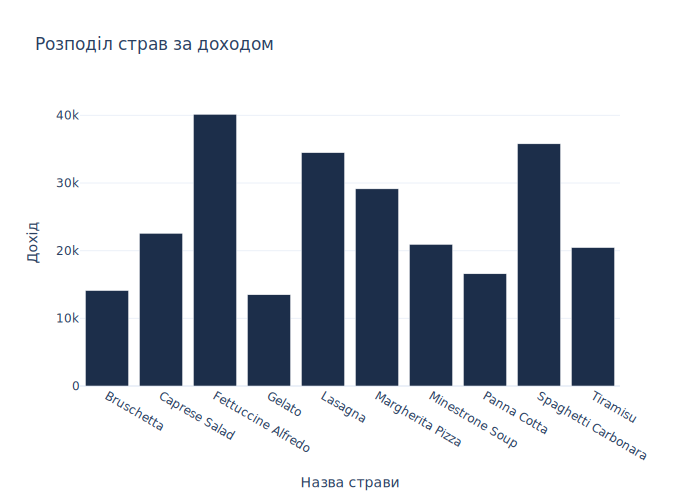

In [11]:
revenue_by_item = df.groupby("menu_item", observed=True)["revenue"].sum()

fig = px.bar(revenue_by_item,
            title = 'Розподіл страв за доходом',
            labels={'menu_item': 'Назва страви', 'value' : 'Дохід'},
             template="plotly_white",
             hover_data={'variable': False},
             color_discrete_sequence=palette_of_df
            )
fig.update_layout(height=500,
                  showlegend=False,
                 )
fig.show()


Найбільш прибутковими позиціями є страви з пасти, де перше місце посідає Fettuccine Alfredo.
Варто розглянути можливість крос-продажів (пропонувати десерти або закуски до популярних паст), щоб підняти дохід від категорій з низькими показниками.

# 2. Що впливає на формування доходу?

In [12]:
revenue_generation = (df.groupby('menu_item', as_index=False, observed=True)
                                .agg(
                                total_quantity = ('quantity', 'sum'),
                                avg_price = ('price', 'mean'),
                                total_revenue = ('revenue', 'sum')
                                )
                                .sort_values('total_revenue', ascending=False)
                     )

revenue_generation

,menu_item,total_quantity,avg_price,total_revenue
2,Fettuccine Alfredo,3089,13.0,40157.0
8,Spaghetti Carbonara,2983,12.0,35796.0
4,Lasagna,2999,11.5,34488.5
5,Margherita Pizza,2914,10.0,29140.0
1,Caprese Salad,2821,8.0,22568.0
6,Minestrone Soup,2990,7.0,20930.0
9,Tiramisu,3148,6.5,20462.0
7,Panna Cotta,3016,5.5,16588.0
0,Bruschetta,2822,5.0,14110.0
3,Gelato,2998,4.5,13491.0


З таблиці видно, що Fettuccine Alfredo та Spaghetti Carbonara є лідерами дохідності завдяки вісокій ціні та об'ємам продажів, у той час як Tiramisu та Panna Cotta теж мають високі обсяги продажів, але через низьку ціну приносять значно менше доходу.

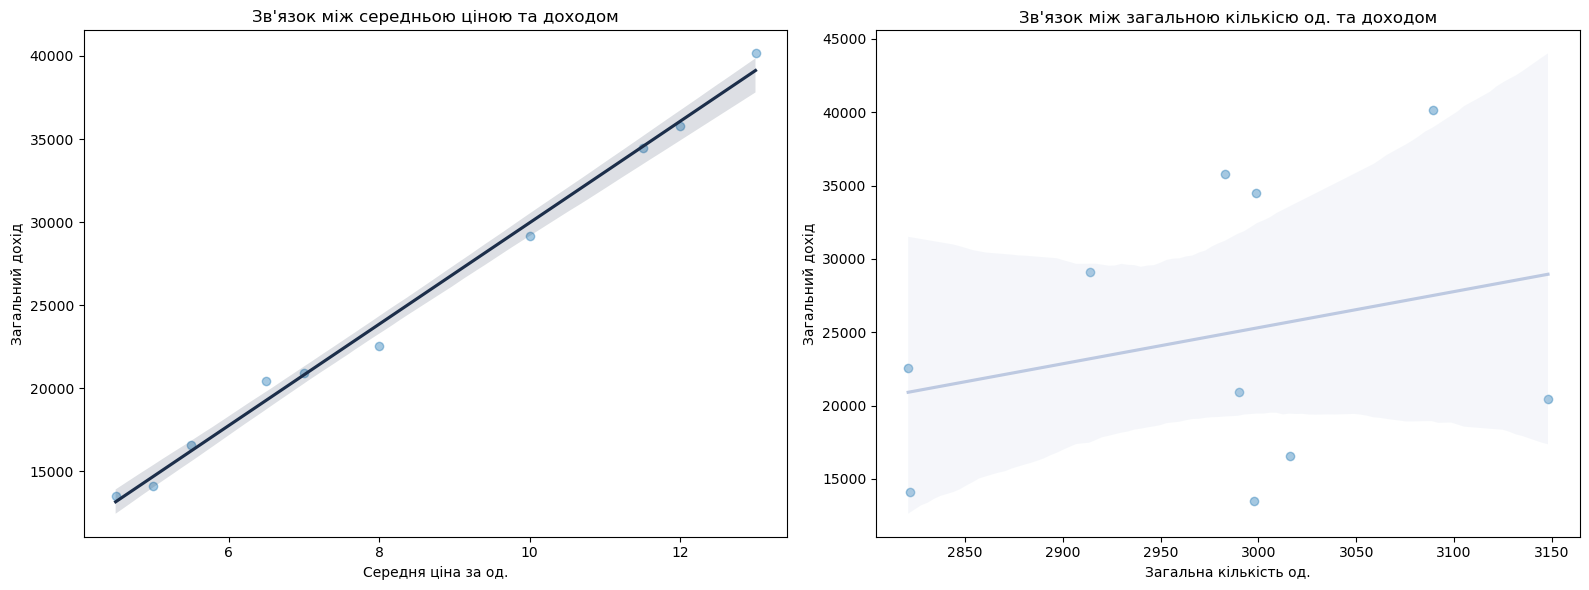

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data = revenue_generation,
            x = 'avg_price',
            y = 'total_revenue',
            scatter_kws = {'alpha': 0.4},
            line_kws = {'color': palette_of_df[0]},
            ax=axes[0]
           )

axes[0].set_title("Зв'язок між середньою ціною та доходом")
axes[0].set_xlabel("Середня ціна за од.")
axes[0].set_ylabel("Загальний дохід")

sns.regplot(data = revenue_generation,
            x = 'total_quantity',
            y = 'total_revenue',
            scatter_kws = {'alpha': 0.4},
            line_kws = {'color': palette_of_df[3]},
            ax=axes[1]
           )

axes[1].set_title("Зв'язок між загальною кількісю од. та доходом")
axes[1].set_xlabel("Загальна кількість од.")
axes[1].set_ylabel("Загальний дохід")

plt.tight_layout()
plt.show()

Дані графіки показують нам сильній вплив зміни ціни на дохідність продукту, водночас взаємозв'язок із кількістю дуже слабкий.
Тому доцільно зосередити увагу на товарах з високою ціною, оскільки вони можуть забезпечити більший дохід. Також для підвищення доходу необхідно оцінити маркетингові стратегії для товарів із низькою ціною, щоб підвищити їхній продаж.

# 3. Як розподіляється дохід між категоріями страв?

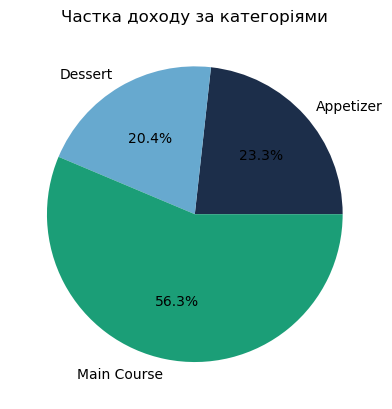

In [14]:
revenue_by_category = df.groupby("category", observed=True)["revenue"].sum()

plt.pie(
    revenue_by_category.values,
    labels=revenue_by_category.index,
    autopct="%1.1f%%",
    colors=palette_of_df
)
plt.title("Частка доходу за категоріями")
plt.show()

Високі показники доходності основних страв свідчать про те, що вони є головним «магнітом» для клієнтів.

# 4. Який тип клієнта є найбільш прибутковим?

In [15]:
customer_revenue = (
    df.groupby("customer_type", as_index=False, observed=True)["revenue"]
    .sum()
)
display(customer_revenue)

,customer_type,revenue
0,Delivery,81536.0
1,Dine-In,83433.5
2,Takeaway,82761.0


Найбільший дохід закладу забезпечують клієнти, що обирають формат Dine-In. Проте, оскільки розрив між лідером та найслабшою категорією мінімальний, можна зробити висновок, що всі канали збуту працюють ефективно та майже однаково важливі для загального прибутку.

# 5. Дохід за типами клієнтів у розрізі категорій меню.

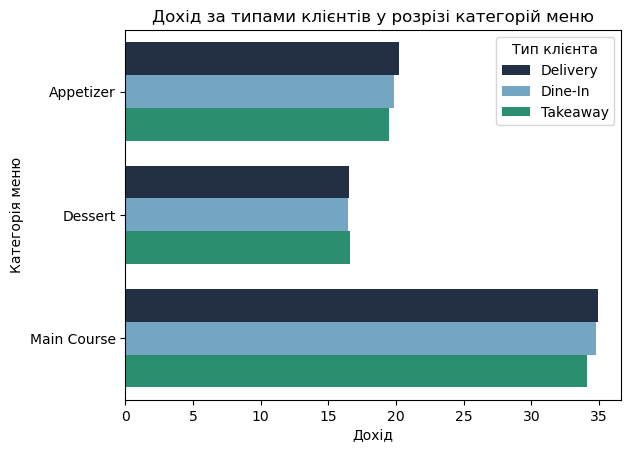

In [16]:
sns.barplot(data=df,
            x='revenue',
            y='category',
            hue='customer_type',
            palette=palette_of_df,
           errorbar=None
           )

plt.title("Дохід за типами клієнтів у розрізі категорій меню")
plt.xlabel("Дохід")
plt.ylabel("Категорія меню")
plt.legend(title='Тип клієнта')
plt.show()

Найбільший дохід приносить обслуговування клієнтів у закладі Dine-In, особливо в категорії Основних страв. Це визначає важливість покращення атмосфери самого ресторану, а також роботи офіціантів. Takeaway та Delivery приносять значно менше доходу, але тут є потенціал для росту через розгляд провадження спеціальних пропозицій чи зменшення часу доставки.

# 6. У які години найбільше замовлень та доходу?

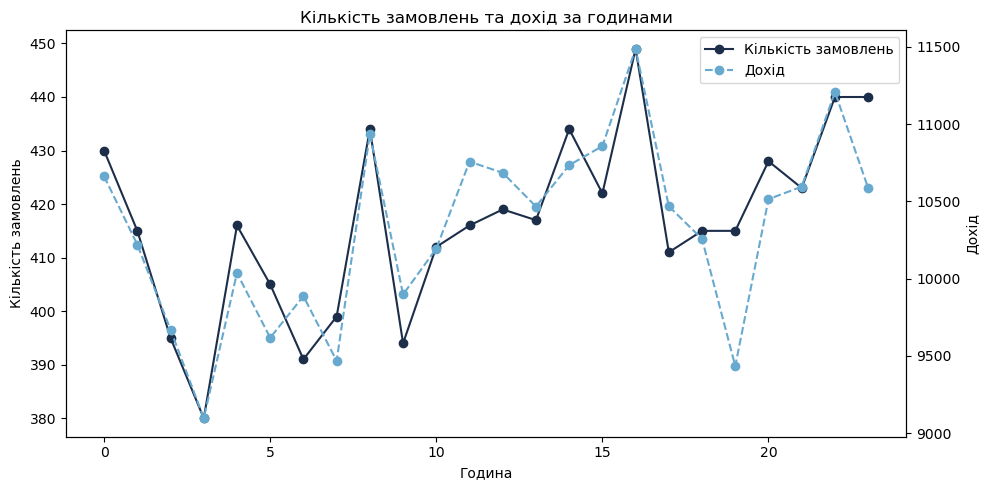

In [17]:
orders_by_hour = (
    df.groupby("hour", as_index=False, observed=True)
    .agg(
        orders_count=("menu_item", "count"),
        revenue=("revenue", "sum"),
    )
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    orders_by_hour["hour"],
    orders_by_hour["orders_count"],
    marker="o",
    label="Кількість замовлень",
    color=palette_of_df[0]
)
ax1.set_xlabel("Година")
ax1.set_ylabel("Кількість замовлень")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(
    orders_by_hour["hour"],
    orders_by_hour["revenue"],
    marker="o",
    linestyle="--",
    label="Дохід",
    color=palette_of_df[1]
)
ax2.set_ylabel("Дохід")
ax2.tick_params(axis="y")

plt.title("Кількість замовлень та дохід за годинами")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()
plt.show()

Графік демонструє нерівномірність навантаження протягом доби. Найбільш прибутковим періодом є друга половина дня, зокрема пік о 16:00. Ранішній пік о 8:00 та пізній вечірній пік о 22:00 вказують на те, що заклад (або сервіс) має стабільний попит у ключові часові проміжки.
Висока різниця між дохідністю та кількістю замовлень о 19:00 свідчить про те, що в цей час частіше купують позиції з низькою ціною.

# 7. Як змінюється попит на різні позиції товарів в залежності від місяця року?

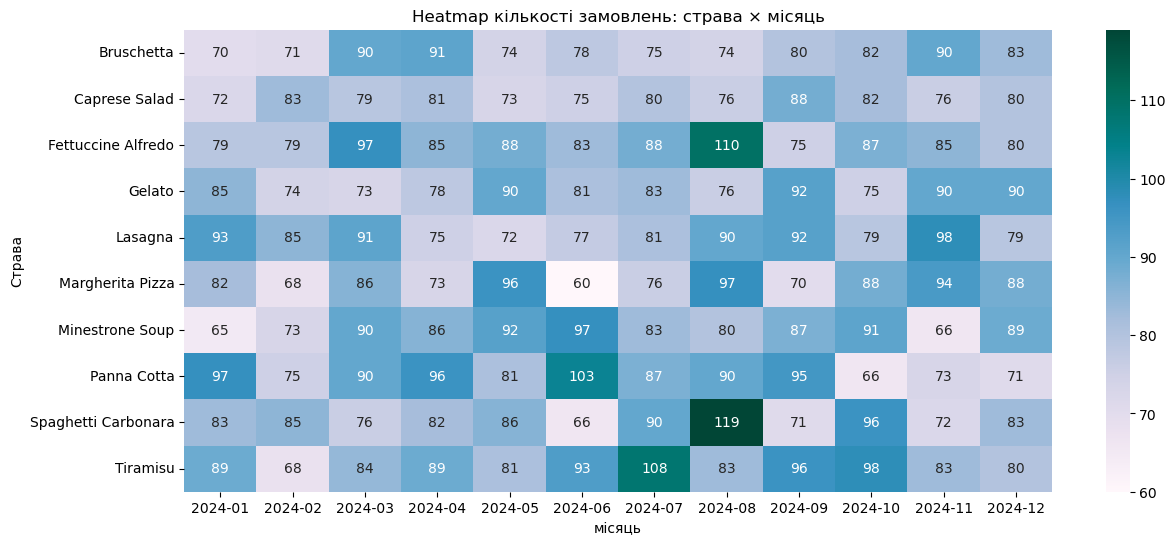

In [18]:
heatmap_data = (
    df.groupby(["menu_item", "month"], observed=True)
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='PuBuGn'
)

plt.title("Heatmap кількості замовлень: страва × місяць")
plt.xlabel("місяць")
plt.ylabel("Страва")
plt.show()

Аналіз розподілу замовлень дозволяє виділити лідерів та «просідання» в асортименті. Найчастіше клієнти замовляли Spaghetti Carbonara та Tiramisu, особливо у другій половині року. Найменша кількість замовлень зафіксована для Minestrone Soup у січні (65) та Margherita Pizza у червні (60). Panna Cotta та Tiramisu мають стабільно високі показники (часто понад 90 замовлень), що свідчить про високу популярність десертного меню.
У літні місяці слід ретельніше слідкувати за закупівлею інгредієнтів для пасти та італійських десертів, оскільки в цей час навантаження на кухню є максимальним.

# 8. Як змінюється попит у різні дні тижня у різних типів клієнтів?

In [19]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["weekday"] = pd.Categorical(
    df["weekday"],
    categories=weekday_order,
    ordered=True
)

In [20]:
weekday_customer = (
    df.groupby(['weekday', 'customer_type'], observed=True)
      .size()
      .unstack(fill_value=0)
)


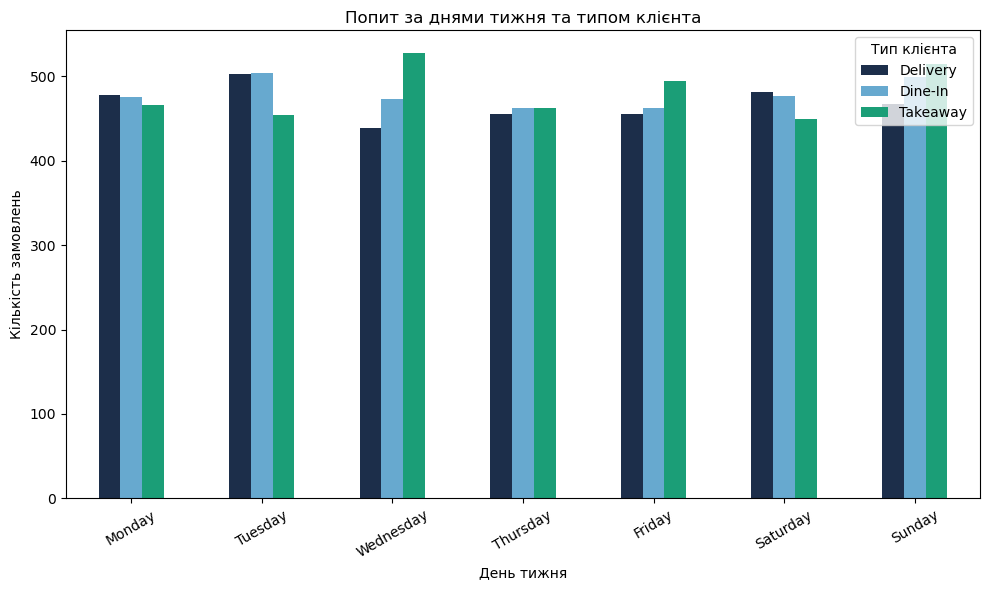

In [21]:
weekday_customer.plot(
    kind='bar',
    #stacked=True,
    figsize=(10, 6),
    color=palette_of_df
)

plt.title('Попит за днями тижня та типом клієнта')
plt.xlabel('День тижня')
plt.ylabel('Кількість замовлень')
plt.xticks(rotation=30)
plt.legend(title='Тип клієнта')

plt.tight_layout()
plt.show()

Візуалізація дозволяє відстежити поведінку різних сегментів клієнтів. Delivery демонструє стабільність протягом тижня з помітним зростанням у вівторок. Пікові значення Dine-In припадають на неділю та вівторок, що є нетиповим для класичних ресторанів. Takeaway - найбільш динамічна категорія. Має найвищий показник у неділю, але суттєво просідає у вівторок та суботу.
Нетипово низький попит на Dine-In та Delivery у суботу порівняно з вівторком потребує додаткового дослідження причин. Також у вівторок та неділю необхідно задіяти максимальну кількість персоналу, оскільки це дні найвищого загального навантаження.

# 9. Чи є сезонність у продажах по місяцях?

In [22]:
month_stats = (
    df.groupby('month', as_index=False)
      .agg(
          total_revenue=('revenue', 'sum'),
          orders_count=('revenue', 'count')
      )
)

month_stats['month'] = month_stats['month'].astype(str)

month_stats = month_stats.sort_values('month')


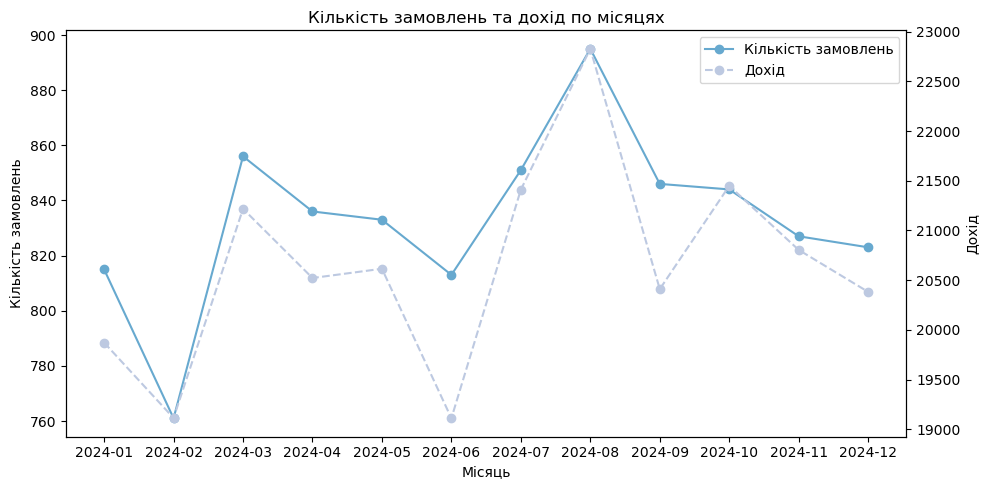

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    month_stats["month"],
    month_stats["orders_count"],
    marker="o",
    label="Кількість замовлень",
    color=palette_of_df[1]
)
ax1.set_xlabel("Місяць")
ax1.set_ylabel("Кількість замовлень")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(
    month_stats["month"],
    month_stats["total_revenue"],
    marker="o",
    linestyle="--",
    label="Дохід",
    color=palette_of_df[3]
)
ax2.set_ylabel("Дохід")
ax2.tick_params(axis="y")

plt.title("Кількість замовлень та дохід по місяцях")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()
plt.show()

Аналіз річних показників свідчить про значні коливання попиту та доходу протягом року. Найуспішнішим місяцем став серпень. У цей період кількість замовлень (близько 895) та дохід (майже 23 000) досягли своїх максимальних значень. Найнижчі показники зафіксовані у лютому та червні. Причому в червні спостерігається різке падіння саме доходу при відносно помірному зниженні кількості замовлень. Загалом графіки кількості замовлень та доходу синхронні, що свідчить про стабільність середнього чека, за винятком червня та вересня, де дохід падав стрімкіше за кількість продажів.

Варто дослідити причини червневого просідання доходу (скоріш за все це пов'язано зі зростанням попиту на більш дешеві страви) та розробити стимулюючі акції для цього періоду.

# 10. Динаміка доходу за категоріями страв протягом року

In [24]:
category_month_revenue = (
    df.groupby(["month", "category"], as_index=False, observed=True)["revenue"]
    .sum()
)

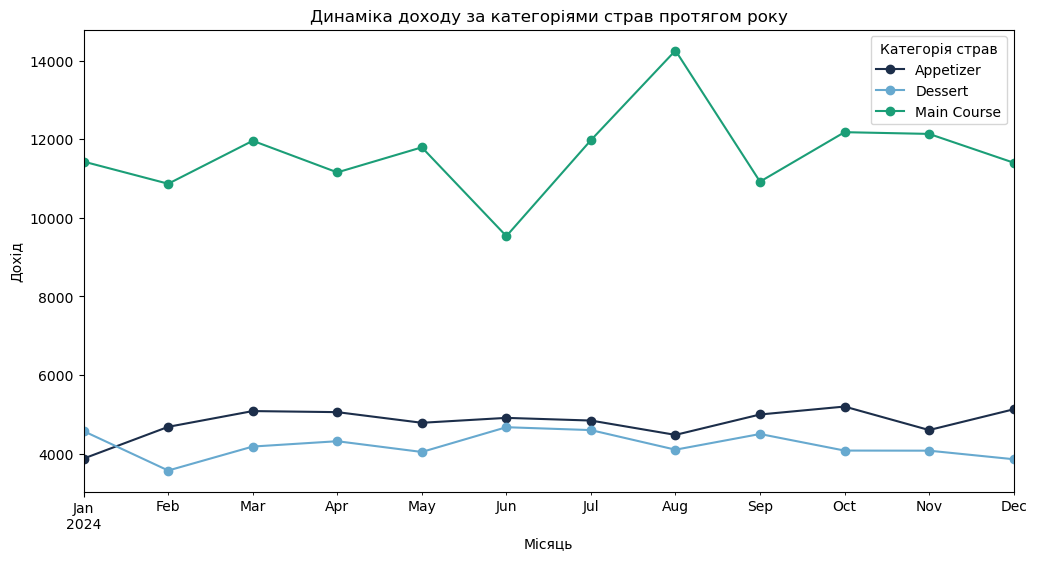

In [25]:
pivot_table = df.pivot_table(
    values="revenue",
    index="month",
    columns="category",
    aggfunc="sum",
    observed=True
)

pivot_table.plot(marker="o", figsize=(12,6), color=palette_of_df)

plt.title("Динаміка доходу за категоріями страв протягом року")
plt.xlabel("Місяць")
plt.ylabel("Дохід")
plt.legend(title="Категорія страв")

plt.show()

Аналіз доходів за категоріями страв протягом 2024 року демонструє чітку ієрархіюю Main Course - беззаперечним лідером за рівнем доходу, стабільно приносячи від 10 000 до 14 000 одиниць щомісяця. Найвищий пік прибутку припав на серпень, а найглибший спад — на червень. Appetizer та Dessert демонструють набагато нижчі, але стабільніші показники доходу (в межах 4 000 – 5 500). При цьому дохід від закусок майже весь рік дещо перевищує дохід від десертів. Коливання доходів в категоріях закусок та десертів часто не збігаються з динамікою основних страв, що свідчить про різну споживчу поведінку клієнтів у різні місяці.

# Загальні висновки

Аналіз продажів свідчить, що найбільшу частку доходу ресторану забезпечують основні страви — понад 56% від загального виторгу. Цей показник суттєво перевищує доходи від закусок (23,25%) та десертів (20,40%). Така ситуація пояснюється передусім вищою середньою ціною основних страв, завдяки чому вони приносять більший прибуток навіть за дещо менших обсягів продажів у порівнянні з іншими категоріями. Крім того, слід зазначити, що попит на закуски та десерти більш стабільний протягом року, коли попит на основні страви демонструє більші коливання.

Детальніший аналіз страв цієї категорії показує, що Феттучіне Альфредо та Спагеті Карбонара є найбільш прибутковими позиціями меню. Це пов’язано з поєднанням високої ціни та значної кількості продажів, що підкреслює важливість не лише вартості страви, а й її популярності серед відвідувачів. Саме баланс між ціною та попитом значною мірою визначає рівень доходу від конкретної позиції.

Натомість закуски та десерти приносять менший дохід, що може бути пов’язано як із нижчою ціною. Це може свідчити про необхідність перегляду асортименту або маркетингової стратегії для цих категорій.

Сезонність також впливає на динаміку продажів. Популярність основних страв дещо знижується у період з березня до червня, тоді як попит на закуски та десерти зростає, про що свідчить значне падіння доходу у порівнянні з кількістю замовлень. У такій ситуації доцільно використовувати сезонні акції, спеціальні пропозиції або комбо-меню, які допоможуть підтримувати рівень доходую

З точки зору бізнес-стратегії ресторану, варто зосередити увагу на просуванні основних страв, оскільки саме вони формують найбільшу частину доходу. Особливо ефективним може бути маркетингове просування популярних і прибуткових позицій, таких як Феттучіне Альфредо, у літній та осінній періоди. Водночас доцільно переглянути підхід до формування меню закусок і десертів, щоб підвищити їхню привабливість для гостей і, відповідно, збільшити прибутковість цих категорій.

Отже, ключовими факторами формування доходу є ціна страви та рівень попиту, особливо в категорії основних страв. Для максимізації прибутку ресторану варто робити акцент на популярних позиціях із високою ціною та стабільним попитом, паралельно оптимізуючи асортимент закусок і десертів для підвищення їхньої комерційної ефективності.